Failures occur at any stage:
- API calls to foundation models
- Unexpected LLM output
- External services / tools become unavailable

## Logging

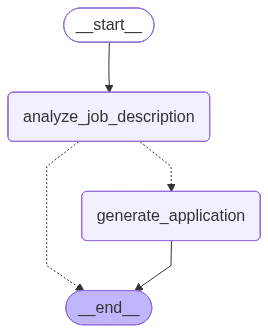

In [24]:
# Continuing from previous workflow
from dotenv import load_dotenv
load_dotenv()
from typing_extensions import TypedDict # Used to define state
from typing import Annotated, Literal # Used for type annotations
from operator import add # Used as state reducer
from pydantic import BaseModel, Field # Used for structured output parsing
from langchain_openai import ChatOpenAI # Used as the language model
from langgraph.graph import StateGraph, START, END # Used to build the state graph


def display_graph(graph):
    """Helper function to display the graph as an image"""
    from IPython.display import Image, display
    display(Image(graph.get_graph().draw_mermaid_png()))


new_prompt_template = (
    "Given a job description, decide whether it suits a junior Java developer."
    "\nJOB DESCRIPTION:\n{job_description}\n"
    "Answer only YES or NO."
)


class ModelResponse(BaseModel):
    suitability: Literal['YES', 'NO'] = Field(..., description='Whether the job description suits a junior Java developer')


model = ChatOpenAI(model='gpt-5-nano')
model_with_format = model.with_structured_output(ModelResponse)

# Define the state structure
class JobApplicationState(TypedDict):
    job_description: str
    is_suitable: bool
    suitability_result: ModelResponse # Include the structured response in the state with proper typing
    application: str
    actions: Annotated[list[str], add]


# Define nodes
def analyze_job_description(state: JobApplicationState):
    prompt = new_prompt_template.format(job_description=state["job_description"])
    result: ModelResponse = model_with_format.invoke(prompt)
    
    return {
        "suitability_result": result,
        "is_suitable": result.suitability == "YES",
    }

def generate_application(state: JobApplicationState):
    ai_message = model.invoke(f"Generate a short job application for the following job description: {state['job_description']}")
    application = ai_message.content
    return {"application": application}


# Define conditional function used for conditional edges in graph
def is_suitable_condition(state: JobApplicationState) -> Literal['generate_application', '__end__']:
    if state.get('is_suitable'):
        return 'generate_application'
    return END


builder = StateGraph(JobApplicationState)
builder.add_node("analyze_job_description", analyze_job_description)
builder.add_node("generate_application", generate_application)
builder.add_edge(START, "analyze_job_description")
builder.add_conditional_edges(
    'analyze_job_description',
    is_suitable_condition
)
builder.add_edge('generate_application', END)
graph = builder.compile()

display_graph(graph)

In [25]:
import logging
logger = logging.getLogger(__name__)

# Define a new version of this node with error handling
def analyze_job_description(state: JobApplicationState):
    try:
        prompt = new_prompt_template.format(job_description=state["job_description"])
        result: ModelResponse = model_with_format.invoke(prompt)
        return {
            "suitability_result": result,
            "is_suitable": result.suitability == "YES",
        }
    except Exception as e:
        logger.error(f'Exception {e} occured while executing analyze_job_description')
        return {
            "is_suitable": False
        }

In [23]:
from langchain_core.language_models.fake_chat_models import GenericFakeChatModel
from langchain.messages import AIMessage

fake_model = GenericFakeChatModel(
    messages = iter([AIMessage(content="WHAT???")])
)
model_with_format = fake_model

# Rebuild with the *current* function definitions
builder = StateGraph(JobApplicationState)
builder.add_node("analyze_job_description", analyze_job_description)
builder.add_node("generate_application", generate_application)
builder.add_edge(START, "analyze_job_description")
builder.add_conditional_edges("analyze_job_description", is_suitable_condition)
builder.add_edge("generate_application", END)
graph = builder.compile()

# Testing
job_description: str = "We are looking for a Data Scientist with experience in Python and LangChain"
result = graph.invoke({'job_description': job_description})

Exception 'AIMessage' object has no attribute 'suitability' occured while executing analyze_job_description


## Retries

In [ ]:
# Generic retry with Runnable - typically used around model calls or API tools
fake_llm_retry = fake_model.with_retry(
    retry_if_exception_type=(ValueError),
    wait_exponential_jitter=True,
    stop_after_attempt=2
)

In [ ]:
# Retry on LangGraph nodes
from langgraph.types import RetryPolicy

some_builder = StateGraph(JobApplicationState)
some_builder.add_node(
    'node_name',
    lambda state: {"key": "value"},
    retry_policy=RetryPolicy(retry_on=ValueError, max_attempts=2)
)

By default, will retry on any exception except for:
- ValueError
- TypeError
- ArithmeticError
- ImportError
- LookupError
- NameError
- SyntaxError
- RuntimeError
- ReferenceError
- StopIteration
- StopAsyncIteration
- OSError